In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Cell 2 — Configuration
FRED_API_KEY = "87c04efcdf543072107e53f957356b52"

# Country ETF Universe
COUNTRY_ETFS = {
    "USA":        "SPY",
    "Brazil":     "EWZ",
    "Japan":      "EWJ",
    "Germany":    "EWG",
    "Canada":     "EWC",
    "Australia":  "EWA",
    "UK":         "EWU",
    "China":      "MCHI",
    "SouthKorea": "EWY",
    "Taiwan":     "EWT",
    "Italy":      "EWI",
    "Spain":      "EWP",
    "India":      "INDA",
}

# Backtest settings
START_DATE = "2004-01-01"
END_DATE   = "2024-12-31"
TOP_N      = 4   # Long top N
BOTTOM_N   = 4   # Short bottom N

print(f"Universe: {len(COUNTRY_ETFS)} country ETFs")
print(f"Period: {START_DATE} to {END_DATE}")

Universe: 13 country ETFs
Period: 2004-01-01 to 2024-12-31


In [3]:
# Cell 3 — Fetch ETF Prices
tickers = list(COUNTRY_ETFS.values())
prices = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)["Close"]
monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change()

print(f"ETF prices shape: {prices.shape}")
print(f"Monthly prices shape: {monthly_prices.shape}")
print(f"\nDate range: {monthly_prices.index[0].date()} to {monthly_prices.index[-1].date()}")
print(f"\nMissing data per ETF:")
print(monthly_prices.isna().sum())

ETF prices shape: (5284, 13)
Monthly prices shape: (252, 13)

Date range: 2004-01-31 to 2024-12-31

Missing data per ETF:
Ticker
EWA      0
EWC      0
EWG      0
EWI      0
EWJ      0
EWP      0
EWT      0
EWU      0
EWY      0
EWZ      0
INDA    97
MCHI    86
SPY      0
dtype: int64


In [4]:
# Cell 4 — Fetch FRED Macro Data
fred = Fred(api_key=FRED_API_KEY)

FRED_SERIES = {
    "fed_funds":     "FEDFUNDS",
    "treasury_10y":  "GS10",
    "treasury_2y":   "GS2",
    "real_yield":    "DFII10",
    "cpi":           "CPIAUCSL",
    "ppi":           "PPIACO",
    "breakeven":     "T10YIE",
    "unemployment":  "UNRATE",
    "jobless_claims":"ICSA",
    "indust_prod":   "INDPRO",
    "cfnai":         "CFNAI",
    "hy_spreads":    "BAMLH0A0HYM2",
}

macro = {}
for name, code in FRED_SERIES.items():
    try:
        s = fred.get_series(code, observation_start=START_DATE, observation_end=END_DATE)
        macro[name] = s
        print(f"  fetched {name}")
    except Exception as e:
        print(f"  FAILED {name}: {e}")

macro = pd.DataFrame(macro)
macro.index = pd.to_datetime(macro.index)
macro = macro.resample("ME").last().ffill()

print(f"\nMacro data shape: {macro.shape}")
print(f"Columns: {list(macro.columns)}")

  fetched fed_funds
  fetched treasury_10y
  fetched treasury_2y
  fetched real_yield
  fetched cpi
  fetched ppi
  fetched breakeven
  fetched unemployment
  fetched jobless_claims
  fetched indust_prod
  fetched cfnai
  fetched hy_spreads

Macro data shape: (252, 12)
Columns: ['fed_funds', 'treasury_10y', 'treasury_2y', 'real_yield', 'cpi', 'ppi', 'breakeven', 'unemployment', 'jobless_claims', 'indust_prod', 'cfnai', 'hy_spreads']


In [5]:
# Cell 5 — Fetch Commodity & Risk Data
COMMODITIES = {
    "oil":    "CL=F",
    "copper": "HG=F",
    "gold":   "GC=F",
    "dxy":    "DX-Y.NYB",
    "vix":    "^VIX",
}

comm_raw = yf.download(list(COMMODITIES.values()), start=START_DATE, end=END_DATE, 
                        auto_adjust=True, progress=False)["Close"]
comm_raw.columns = list(COMMODITIES.keys())
commodities = comm_raw.resample("ME").last().ffill()

print(f"Commodity data shape: {commodities.shape}")
print(f"\nMissing data:")
print(commodities.isna().sum())
print(f"\nLatest values:")
print(commodities.tail(1).round(2))

Commodity data shape: (252, 5)

Missing data:
oil       0
copper    0
gold      0
dxy       0
vix       0
dtype: int64

Latest values:
              oil  copper    gold   dxy   vix
Date                                         
2024-12-31  70.99  108.13  2606.1  4.05  17.4


In [32]:
# Cell 6 revised — only use signals that actually work
signals = pd.DataFrame(index=macro.index)

# STRONG signals — keep as is
signals["cpi"]        = zscore(-macro["cpi"].pct_change(12))        # low inflation = bullish
signals["ppi"]        = zscore(-macro["ppi"].pct_change(12))        # low PPI = bullish  
signals["cfnai"]      = zscore(macro["cfnai"])                      # strong growth = bullish
signals["real_yield"] = zscore(-macro["real_yield"])                # low real yield = bullish
signals["indust_prod"]= zscore(macro["indust_prod"].pct_change(3))  # rising IP = bullish

# MODERATE signals — keep
signals["fed_funds"]  = zscore(-macro["fed_funds"].diff(3))         # rate cuts = bullish
signals["breakeven"]  = zscore(macro["breakeven"].diff(3))          # rising inflation expectations = bullish
signals["gold"]       = zscore(commodities["gold"].pct_change(3))   # gold rising = bullish
signals["oil"]        = zscore(commodities["oil"].pct_change(3))    # oil momentum

# FIXED direction signals
signals["hy_spreads"] = zscore(macro["hy_spreads"].diff(3))         # FLIPPED — rising spreads = bearish was wrong
signals["dxy"]        = zscore(commodities["dxy"].pct_change(3))    # FLIPPED — strong dollar = bullish for some
signals["vix"]        = zscore(commodities["vix"])                  # FLIPPED — high vix = risk off

# DROPPED: yield_curve, unemployment, jobless_claims, copper — too weak

# Normalize
signals_norm = signals.sub(signals.mean()).div(signals.std())

print("Signals rebuilt — keeping only predictive ones")
print(f"Number of signals: {len(signals.columns)}")
print(f"\nSignal preview:")
print(signals_norm.tail(3).round(2))

Signals rebuilt — keeping only predictive ones
Number of signals: 12

Signal preview:
             cpi   ppi  cfnai  real_yield  indust_prod  fed_funds  breakeven  \
2024-10-31  0.85  0.29  -1.02       -0.59        -0.40       1.20       0.59   
2024-11-30  0.75  0.19   0.33       -0.54        -1.04       1.37       0.70   
2024-12-31  0.66  0.07   1.36       -0.78         0.93       1.25       0.96   

            gold   oil  hy_spreads   dxy   vix  
2024-10-31  1.30 -0.61       -1.03  0.28  0.52  
2024-11-30  0.37 -0.39       -1.31 -0.21 -0.75  
2024-12-31 -0.72  0.32        0.45 -0.93 -0.22  


In [34]:
# Cell 7 revised — use only kept signals
scores = pd.DataFrame(index=signals_norm.index, columns=list(SENSITIVITY.keys()), dtype=float)

# Only use signals that exist in signals_norm
macro_cols = ["cpi", "ppi", "cfnai", "real_yield", "indust_prod", 
              "fed_funds", "breakeven", "hy_spreads", "vix"]

for date in signals_norm.index:
    s = signals_norm.loc[date]
    
    base = s[macro_cols].mean()
    
    for ticker, sens in SENSITIVITY.items():
        comm = (s["oil"]  * sens["oil"]    +
                s["gold"] * sens["gold"]   +
                s["dxy"]  * sens["dxy"])
        
        if date in monthly_returns.index and ticker in monthly_returns.columns:
            idx = monthly_returns.index.get_loc(date)
            if idx >= 12:
                mom = monthly_returns[ticker].iloc[idx-12:idx-1].add(1).prod() - 1
            else:
                mom = 0
        else:
            mom = 0
        
        scores.loc[date, ticker] = base + 0.3 * comm + 0.5 * mom

print("Scores rebuilt with cleaned signals")
print(f"\nAverage scores:")
avg = scores.mean().sort_values(ascending=False)
for ticker, score in avg.items():
    country = {v:k for k,v in COUNTRY_ETFS.items()}[ticker]
    print(f"  {country:<12} {score:.3f}")

Scores rebuilt with cleaned signals

Average scores:
  Brazil       0.057
  USA          0.049
  Taiwan       0.046
  Australia    0.044
  SouthKorea   0.043
  Canada       0.038
  Germany      0.036
  Spain        0.030
  UK           0.024
  Italy        0.023
  India        0.022
  Japan        0.022
  China        0.005


In [35]:
# Cell 7b — Market Regime Filter
# If US momentum is dominant, tilt heavily towards SPY
# If international markets are hot, run full strategy

# 12 month rolling return on SPY vs equal weight international
spy_12m = monthly_prices["SPY"].pct_change(12)
intl_tickers = [t for t in list(SENSITIVITY.keys()) if t != "SPY"]
intl_12m = monthly_prices[intl_tickers].mean(axis=1).pct_change(12)

# Regime: how much is SPY outperforming international?
us_dominance = spy_12m - intl_12m

regime = pd.Series("International", index=scores.index)
regime[us_dominance > 0.10]  = "US_Dominant"   # SPY beating intl by >10%
regime[us_dominance < -0.10] = "International"  # Intl beating SPY by >10%
regime[(us_dominance >= -0.10) & (us_dominance <= 0.10)] = "Neutral"

print("Regime distribution:")
print(regime.value_counts())
print()
print("Sample recent regimes:")
print(regime.tail(12))

Regime distribution:
Neutral          106
US_Dominant       93
International     53
Name: count, dtype: int64

Sample recent regimes:
2024-01-31    US_Dominant
2024-02-29    US_Dominant
2024-03-31    US_Dominant
2024-04-30    US_Dominant
2024-05-31    US_Dominant
2024-06-30    US_Dominant
2024-07-31    US_Dominant
2024-08-31        Neutral
2024-09-30    US_Dominant
2024-10-31    US_Dominant
2024-11-30    US_Dominant
2024-12-31    US_Dominant
Freq: ME, dtype: object


In [36]:
# Cell 8 revised — Regime-Aware Strategy
TOP_N = 4
portfolio_returns = []
weights_history  = []
tickers = list(SENSITIVITY.keys())

for i in range(1, len(scores)):
    date      = scores.index[i]
    prev_date = scores.index[i-1]
    
    row = scores.loc[prev_date].dropna()
    if len(row) < TOP_N:
        continue
    
    # Get regime for previous month (no lookahead)
    current_regime = regime.loc[prev_date] if prev_date in regime.index else "Neutral"
    
    target = pd.Series(0.0, index=tickers)
    
    if current_regime == "US_Dominant":
        # Just hold SPY
        target["SPY"] = 1.0
        
    elif current_regime == "International":
        # Full strategy — long top 4 ex-SPY
        row_ex_spy = row.drop("SPY", errors="ignore")
        ranked = row_ex_spy.rank(ascending=False)
        longs  = ranked[ranked <= TOP_N].index.tolist()
        target[longs] = 1.0 / TOP_N
        
    else:  # Neutral
        # 50% SPY, 50% top 3 international
        target["SPY"] = 0.50
        row_ex_spy = row.drop("SPY", errors="ignore")
        ranked = row_ex_spy.rank(ascending=False)
        longs  = ranked[ranked <= 3].index.tolist()
        target[longs] = 0.50 / 3
    
    if date not in monthly_returns.index:
        continue
    ret = monthly_returns.loc[date]
    
    gross    = (target * ret).sum()
    prev_w   = weights_history[-1]["weights"] if weights_history else pd.Series(0.0, index=tickers)
    turnover = (target - prev_w).abs().sum()
    tx_cost  = turnover * (COMMISSION + SLIPPAGE)
    net      = gross - tx_cost
    
    portfolio_returns.append({"date": date, "gross": gross,
                               "tx_cost": tx_cost, "net": net,
                               "regime": current_regime})
    weights_history.append({"date": date, "weights": target.copy()})

df_returns = pd.DataFrame(portfolio_returns).set_index("date")
df_returns["cum_net"]   = (1 + df_returns["net"]).cumprod()
df_returns["cum_gross"] = (1 + df_returns["gross"]).cumprod()
spy_ret = monthly_returns["SPY"].reindex(df_returns.index)
cum_spy = (1 + spy_ret).cumprod()

rf         = macro["fed_funds"].reindex(df_returns.index).ffill() / 100 / 12
excess     = df_returns["net"] - rf
sharpe     = excess.mean() / excess.std() * np.sqrt(12)
total_ret  = df_returns["cum_net"].iloc[-1] - 1
max_dd     = ((df_returns["cum_net"] / df_returns["cum_net"].cummax()) - 1).min()
spy_sharpe = ((spy_ret - rf).mean() / (spy_ret - rf).std()) * np.sqrt(12)

print("=== Regime-Aware Strategy vs SPY ===")
print(f"\n  Gross return:      {df_returns['gross'].mean()*12:.2%}")
print(f"  Transaction costs: {df_returns['tx_cost'].mean()*12:.2%}")
print(f"  Net return:        {df_returns['net'].mean()*12:.2%}")
print(f"  Sharpe ratio:      {sharpe:.2f}")
print(f"  Max drawdown:      {max_dd:.2%}")
print(f"  Total return:      {total_ret:.2%}")
print(f"\n  SPY Sharpe:        {spy_sharpe:.2f}")
print(f"  SPY Total return:  {(cum_spy.iloc[-1]-1):.2%}")

print(f"\nReturns by regime:")
print(df_returns.groupby("regime")["net"].mean().apply(lambda x: f"{x*12:.2%}"))

=== Regime-Aware Strategy vs SPY ===

  Gross return:      10.45%
  Transaction costs: 1.13%
  Net return:        9.33%
  Sharpe ratio:      0.47
  Max drawdown:      -47.12%
  Total return:      382.63%

  SPY Sharpe:        0.63
  SPY Total return:  623.73%

Returns by regime:
regime
International    13.30%
Neutral           6.04%
US_Dominant      11.42%
Name: net, dtype: object


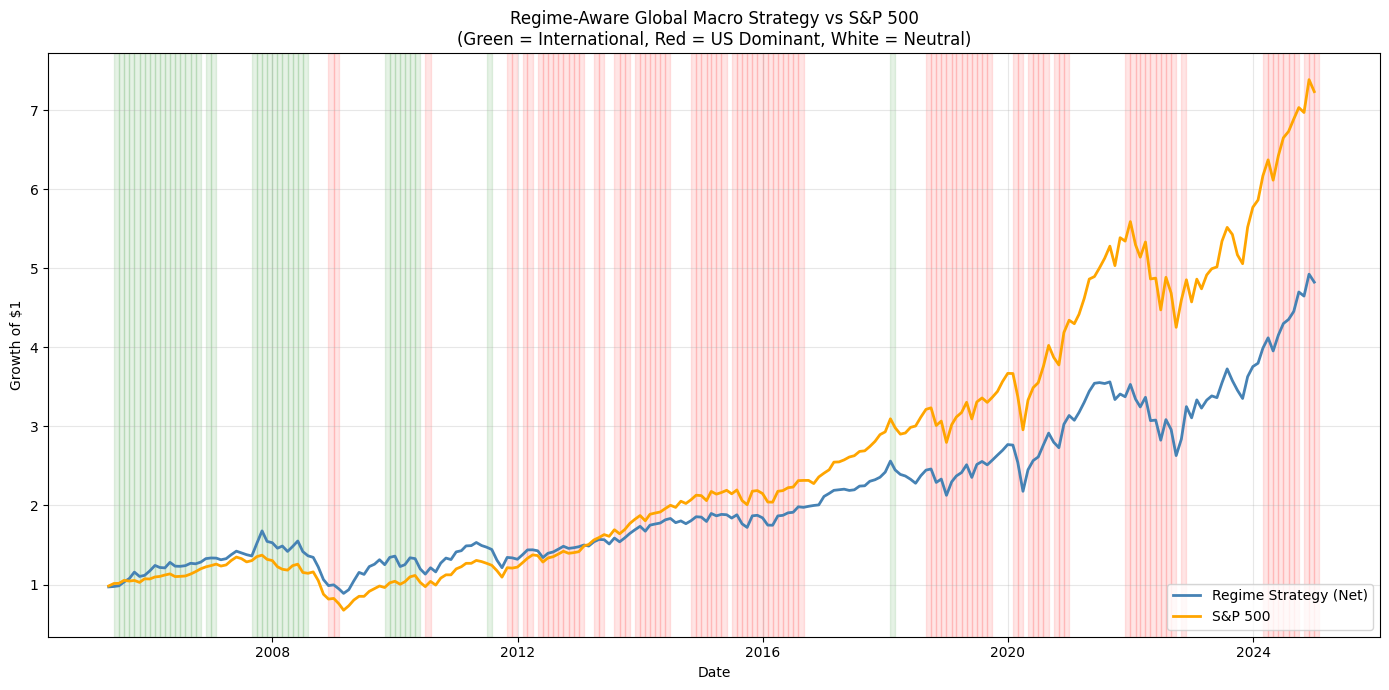

In [37]:
# Cell 9 — Plot
plt.figure(figsize=(14, 7))
plt.plot(df_returns["cum_net"], label="Regime Strategy (Net)", 
         color="steelblue", linewidth=2)
plt.plot(cum_spy, label="S&P 500", color="orange", linewidth=2)

# Shade regimes
for date, row in df_returns.iterrows():
    if row["regime"] == "International":
        plt.axvspan(date, date + pd.offsets.MonthEnd(1), 
                   alpha=0.1, color="green")
    elif row["regime"] == "US_Dominant":
        plt.axvspan(date, date + pd.offsets.MonthEnd(1), 
                   alpha=0.1, color="red")

plt.title("Regime-Aware Global Macro Strategy vs S&P 500\n(Green = International, Red = US Dominant, White = Neutral)")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Annual returns — strategy vs SPY vs each country
annual_strategy = df_returns["net"].resample("YE").apply(lambda x: (1+x).prod()-1)
annual_spy = spy_ret.resample("YE").apply(lambda x: (1+x).prod()-1)
annual_countries = monthly_returns[list(SENSITIVITY.keys())].resample("YE").apply(lambda x: (1+x).prod()-1)

print("Year  Strategy    SPY     Best Country        Worst Country")
print("-" * 65)
for year in annual_strategy.index:
    strat = annual_strategy.loc[year]
    spy   = annual_spy.loc[year]
    
    if year in annual_countries.index:
        best_ticker  = annual_countries.loc[year].idxmax()
        worst_ticker = annual_countries.loc[year].idxmin()
        best_ret     = annual_countries.loc[year].max()
        worst_ret    = annual_countries.loc[year].min()
        best_country  = {v:k for k,v in COUNTRY_ETFS.items()}.get(best_ticker, best_ticker)
        worst_country = {v:k for k,v in COUNTRY_ETFS.items()}.get(worst_ticker, worst_ticker)
        print(f"{year.year}  {strat:+.1%}  {spy:+.1%}   {best_country:<10} {best_ret:+.1%}   {worst_country:<10} {worst_ret:+.1%}")

Year  Strategy    SPY     Best Country        Worst Country
-----------------------------------------------------------------
2005  +17.0%  +7.0%   SouthKorea +53.9%   China      +0.0%
2006  +20.9%  +15.8%   Spain      +49.2%   China      +0.0%
2007  +24.4%  +5.1%   Brazil     +74.8%   Japan      -5.5%
2008  -42.1%  -36.8%   China      +0.0%   SouthKorea -56.0%
2009  +23.4%  +26.4%   Brazil     +122.0%   China      +0.0%
2010  +6.1%  +15.1%   SouthKorea +29.6%   Spain      -18.8%
2011  -12.6%  +1.9%   USA        +1.9%   Brazil     -24.1%
2012  +12.6%  +16.0%   Germany    +32.3%   Brazil     +0.4%
2013  +23.6%  +32.3%   USA        +32.3%   Brazil     -17.5%
2014  +9.2%  +13.5%   India      +21.8%   Brazil     -15.5%
2015  -3.1%  +1.2%   Japan      +9.2%   Brazil     -41.8%
2016  +9.6%  +12.0%   Brazil     +64.5%   Italy      -8.6%
2017  +23.8%  +21.7%   China      +54.7%   Canada     +15.7%
2018  -7.7%  -4.6%   Brazil     -2.5%   Germany    -21.4%
2019  +33.0%  +31.2%   Taiwan     +33.4

In [31]:
# Analyse each signal's predictive power individually
results = []

signal_cols = signals_norm.columns.tolist()
all_returns = monthly_returns[list(SENSITIVITY.keys())].stack()

for sig in signal_cols:
    sig_vals = signals_norm[sig]
    
    combined = []
    for ticker in list(SENSITIVITY.keys()):
        s = sig_vals.to_frame("signal")
        r = monthly_returns[ticker].shift(-1).to_frame("next_ret")
        merged = s.join(r).dropna()
        combined.append(merged)
    
    df_sig = pd.concat(combined)
    correlation = df_sig["signal"].corr(df_sig["next_ret"])
    
    # Quintile spread
    df_sig["quintile"] = pd.qcut(df_sig["signal"], 5, labels=False, duplicates="drop")
    q5 = df_sig[df_sig["quintile"]==4]["next_ret"].mean() * 12
    q1 = df_sig[df_sig["quintile"]==0]["next_ret"].mean() * 12
    spread = q5 - q1
    
    results.append({"signal": sig, "correlation": correlation, "Q5-Q1 spread": spread})

df_signals = pd.DataFrame(results).set_index("signal").sort_values("Q5-Q1 spread", ascending=False)
print("Signal Predictive Power (Q5-Q1 annual spread):")
print(df_signals.round(4).to_string())

Signal Predictive Power (Q5-Q1 annual spread):
                correlation  Q5-Q1 spread
signal                                   
cpi                  0.1890        0.4412
ppi                  0.1307        0.3237
cfnai                0.0781        0.2324
real_yield           0.0001        0.1202
fed_funds            0.0155        0.0768
indust_prod          0.0830        0.0713
oil                  0.0409        0.0705
breakeven            0.0550        0.0691
gold                 0.0352        0.0631
unemployment         0.0052        0.0511
jobless_claims       0.0422        0.0294
copper              -0.0841        0.0069
yield_curve         -0.0125       -0.1024
vix                  0.0136       -0.1333
dxy                 -0.1280       -0.2766
hy_spreads          -0.4430       -0.7307
